In [95]:
from qiskit_encore.preparable_statevector import BigUnitaryPreparableStatevector
from qiskit_phase_propagator.sample_based_manual import (
    phase_propagate_one_cycle,
    phase_propagate_state,
    phase_propagate_state_with_arbitrary_signal,
)
from wave_optics_propagation.visualization import plot_wavefunction

In [96]:
psi = BigUnitaryPreparableStatevector([1, 2, 2, 1, 1, 2, 2, 1], normalize=True)
phi = BigUnitaryPreparableStatevector([0, 5, 2, 3], normalize=True)
# psi = BigUnitaryPreparableStatevector([1, 2, 2, 1], normalize=True)
# phi = BigUnitaryPreparableStatevector([1, 0, 0, 0], normalize=True)

In [97]:
# psi.tensor(phi).draw("latex")

In [98]:
# from qiskit_signals.sample_based_signal import Statevector

# ZERO_STATE = Statevector.from_label("0" * 2)
# ZERO_STATE.tensor

(<Figure size 1280x480 with 2 Axes>,
 (<Axes: xlabel='$|x\\rangle$', ylabel='$|\\psi(x)|$'>,
  <Axes: xlabel='$|x\\rangle$', ylabel='$\\angle\\psi(x)$'>))

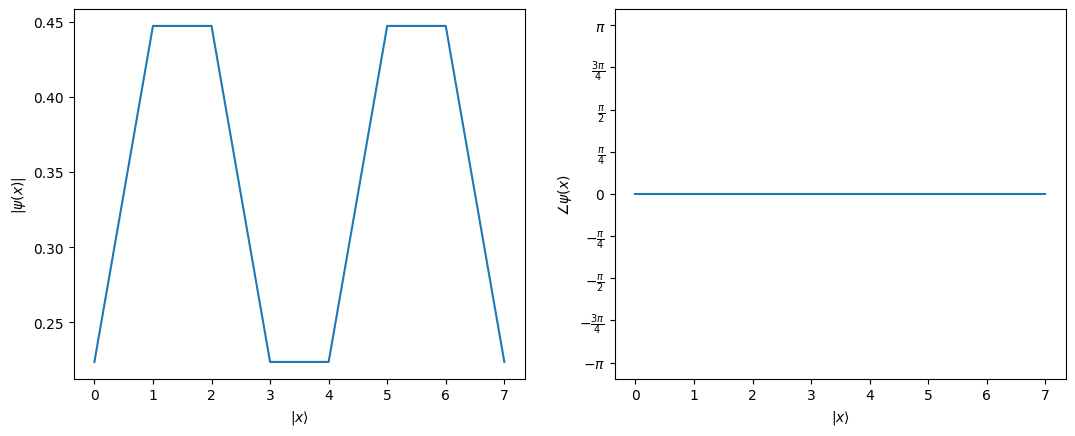

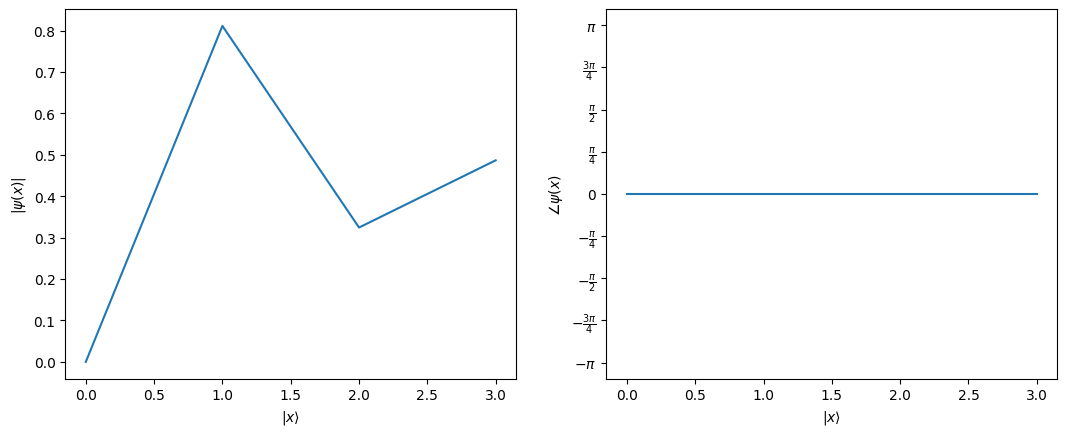

In [99]:
plot_wavefunction(psi)
plot_wavefunction(phi)

In [100]:
output_state = phase_propagate_one_cycle(psi_in=psi, delta=0.5, phi=phi)

Using big matrix state initializer.
direct de-initializer
Using big matrix state de-initializer.


(<Figure size 1280x480 with 2 Axes>,
 (<Axes: xlabel='$|x\\rangle$', ylabel='$|\\psi(x)|$'>,
  <Axes: xlabel='$|x\\rangle$', ylabel='$\\angle\\psi(x)$'>))

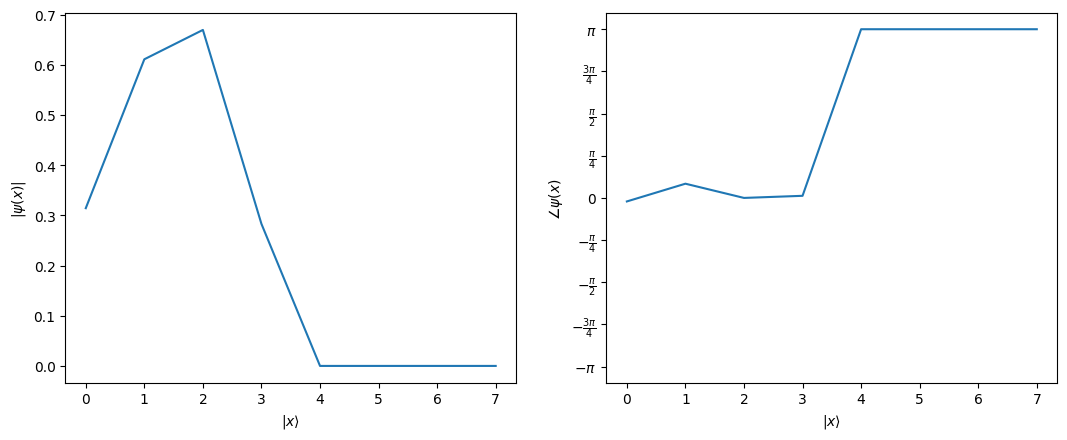

In [101]:
plot_wavefunction(output_state)

In [102]:
output_state_2 = phase_propagate_state(psi_in=psi, deltas=[0.01] * 200, phi=phi)

(<Figure size 1280x480 with 2 Axes>,
 (<Axes: xlabel='$|x\\rangle$', ylabel='$|\\psi(x)|$'>,
  <Axes: xlabel='$|x\\rangle$', ylabel='$\\angle\\psi(x)$'>))

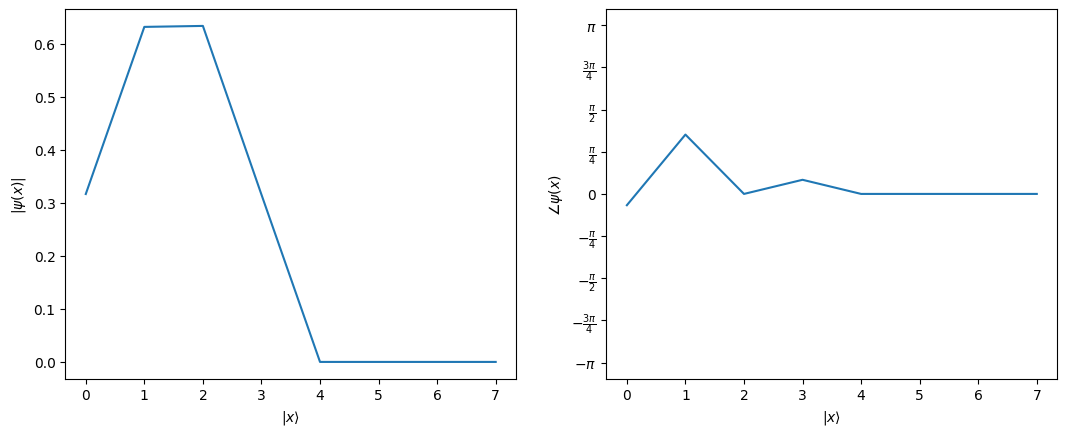

In [103]:
plot_wavefunction(output_state_2)

In [104]:
import numpy as np
from qiskit_signals.helper_types import EncodingType
from qiskit_signals.quantum_axis import PositionAxis
from qiskit_signals.sample_based_signal import ArbitrarySignalForSampleBasedProtocol

x_axis = PositionAxis(psi.num_qubits, delta_x=1, encoding=EncodingType.UNSIGNED)


def gaussian(x):
    return 2 * np.exp(-((x - psi.dim // 2) ** 2) / 4)


signal = ArbitrarySignalForSampleBasedProtocol(x_axis, gaussian)
output_3 = phase_propagate_state_with_arbitrary_signal(
    psi_in=psi, signal=signal, max_delta=0.01
)

Using big matrix state initializer.
direct de-initializer
Using big matrix state de-initializer.


(<Figure size 1280x480 with 2 Axes>,
 (<Axes: xlabel='$|x\\rangle$', ylabel='$|\\psi(x)|$'>,
  <Axes: xlabel='$|x\\rangle$', ylabel='$\\angle\\psi(x)$'>))

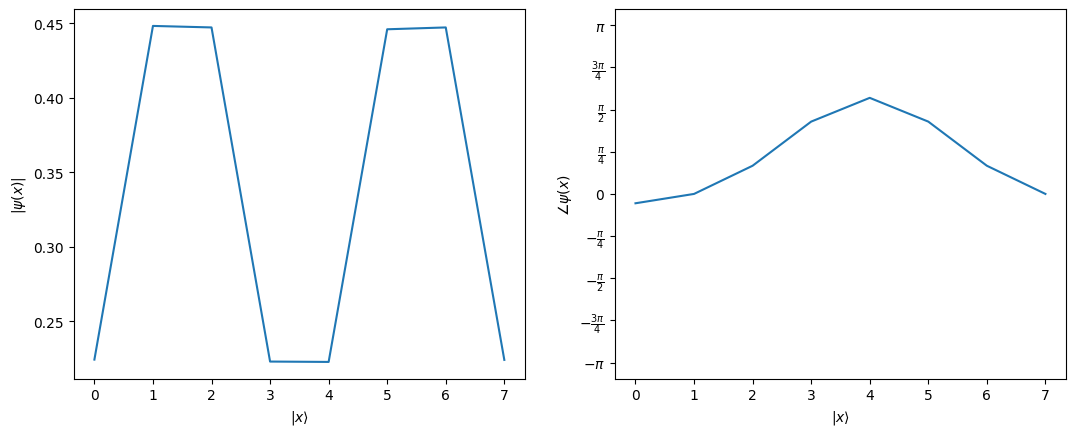

In [105]:
plot_wavefunction(output_3)